In [1]:
# Using branch maf_proto of rubin_sim

In [2]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as splat
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os

from rubin_sim.splat.plots import bright_filter_colors

from rubin_scheduler.utils import (
    angular_separation,
    ddf_locations,hpid2_ra_dec)

from rubin_sim.data import get_baseline
from os.path import basename

from astropy import units as u
from astropy.coordinates import SkyCoord, GeocentricMeanEcliptic

In [3]:
# Database files from https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.3/shrink_fp/
filenames = ["shrink_fp_dust_0.199_v5.3.6_10yrs.db", "shrink_fp_dust_0.080_v5.3.6_10yrs.db"]

In [4]:
hp_arrays = {}
infos = {}

for filename in filenames:
    data_source = basename(filename).replace('.db', '')
    con = sqlite3.connect(filename)
    df = pd.read_sql('select * from observations;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)

    info = {"data_source": data_source}
    is_ddf = np.array(["DD" in note for note in visits_array["scheduler_note"]])
    is_too = np.array(["ToO" in note for note in visits_array["scheduler_note"]])
    sub_data = visits_array[np.where((~is_ddf ) & (~is_too) & (visits_array["visitExposureTime"] > 20))]
    info['observations_subset'] = "No DDF, exp time > 20, no ToO" 
    sl = splat.Slicer()
    metric = splat.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)

    hp_arrays[data_source] = hp_array
    infos[data_source] = info

In [5]:
eclip_coords = SkyCoord(lon=np.arange(361)*u.degree, lat=np.zeros(361)*u.degree, frame=GeocentricMeanEcliptic)
eclip_coords_plus = SkyCoord(lon=np.arange(361)*u.degree, lat=(np.zeros(361)+10)*u.degree, frame=GeocentricMeanEcliptic)
eclip_coords_minus = SkyCoord(lon=np.arange(361)*u.degree, lat=(np.zeros(361)-10)*u.degree, frame=GeocentricMeanEcliptic)

radec_coords = eclip_coords.icrs
radec_coords_plus = eclip_coords_plus.icrs
radec_coords_minus = eclip_coords_minus.icrs

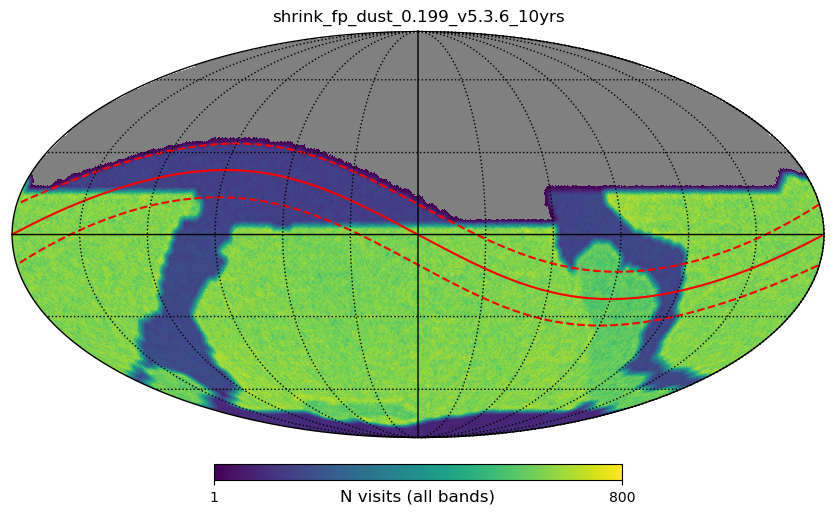

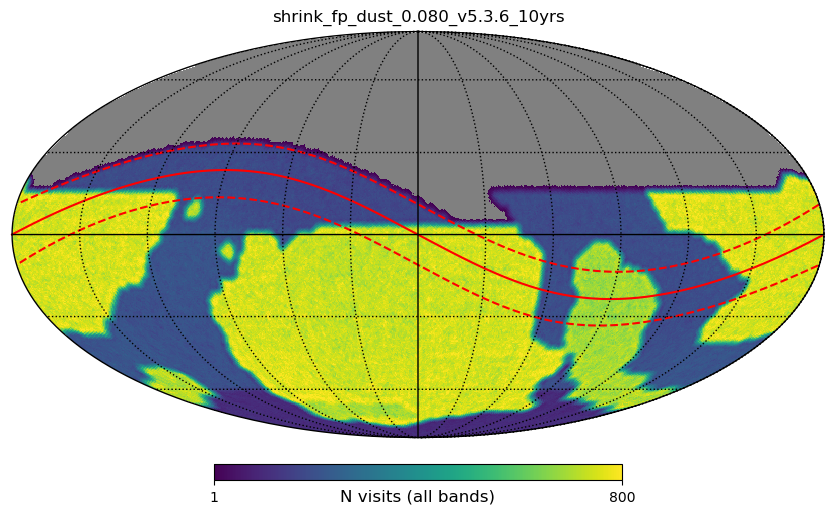

In [12]:
for key in infos.keys():
    hp.mollview(hp_arrays[key], title=key, unit="N visits (all bands)", max=800)
    _temp = hp.projplot(radec_coords.ra.deg,radec_coords.dec.deg,  color="red", lonlat=True)
    _temp = hp.projplot(radec_coords_plus.ra.deg,radec_coords_plus.dec.deg,  color="red", linestyle="--", lonlat=True)
    _temp = hp.projplot(radec_coords_minus.ra.deg,radec_coords_minus.dec.deg,  color="red", linestyle="--", lonlat=True)
    _temp = hp.graticule()

In [7]:
diff_map =  hp_arrays["shrink_fp_dust_0.080_v5.3.6_10yrs"] - hp_arrays["shrink_fp_dust_0.199_v5.3.6_10yrs"]

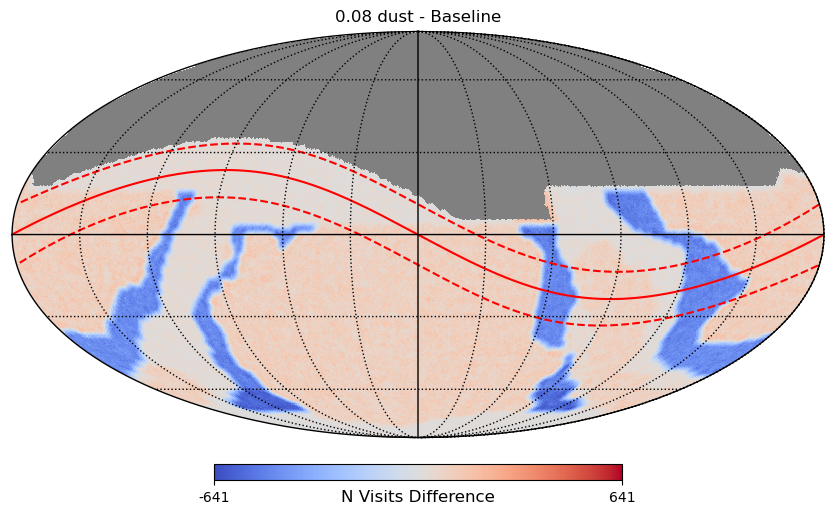

In [11]:

mm = np.max([np.abs(np.nanmin(diff_map)), np.nanmax(diff_map)])

hp.mollview(diff_map, cmap="coolwarm", min=-mm, max=mm, title="0.08 dust - Baseline", unit="N Visits Difference")

_temp = hp.projplot(radec_coords.ra.deg,radec_coords.dec.deg,  color="red", lonlat=True)
_temp = hp.projplot(radec_coords_plus.ra.deg,radec_coords_plus.dec.deg,  color="red", linestyle="--", lonlat=True)
_temp = hp.projplot(radec_coords_minus.ra.deg,radec_coords_minus.dec.deg,  color="red", linestyle="--", lonlat=True)
_temp = hp.graticule()